# Predictive Modeling of Used Car Prices Using Multiple Regression Analysis

Replicates the methodology from *Predicting Used Car Prices* on the
`CAR_DETAILS_FROM_CAR_DEKHO.csv` dataset (4,340 listings):
 
1. Import the Required Libraries
2. Load Dataset
3. Data Cleaning (`Electric` fuel, `Test Drive Car` owner)
4. Feature engineering: `age`, capped `km_driven`
5. Encode categoricals (fuel, seller type, transmission, owner)
6. Log-transform the target (`selling_price`)
7. 80/20 train/test split
8. Fit OLS multiple regression
9. Evaluate: R², Adjusted R², RMSE, MAE, MAPE (log scale AND real-price scale)
10. Diagnostics: Durbin-Watson (autocorrelation), VIF (multicollinearity)
11. Interpret coefficients as % price impact + a Good Deal/Fairly Priced/Overpriced tool

Each section reports our numbers so they can be compared directly against the
paper's Table 1 (coefficients) and Table 2 (metrics).

# Step 1: Import the Required Libraries

## Objective
Import all the Python libraries required for data preprocessing, visualization, feature engineering, model building, statistical analysis, and performance evaluation.

## Explanation
Different libraries are used throughout this project because each one provides specialised tools. Pandas and NumPy are used for data manipulation, Matplotlib for visualisation, Statsmodels for Ordinary Least Squares (OLS) regression and statistical diagnostics, while Scikit-learn provides functions for data splitting, preprocessing, model training, and evaluation.

## Expected Outcome
After executing this cell, all the required libraries will be available, allowing us to proceed with data cleaning, exploratory analysis, regression modelling, and model evaluation.

In [16]:
# Import the Pandas library for loading and manipulating tabular data
import pandas as pd

# Import NumPy for numerical and mathematical operations
import numpy as np

# Import Matplotlib for creating graphs and visualisations
import matplotlib.pyplot as plt

# Import Statsmodels to perform Ordinary Least Squares (OLS) regression
import statsmodels.api as sm

# Import the Variance Inflation Factor (VIF) function
# to detect multicollinearity among predictor variables
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Import the Durbin-Watson statistic
# to check whether residuals are independent
from statsmodels.stats.stattools import durbin_watson

# Import train_test_split to divide the dataset into
# training and testing sets
from sklearn.model_selection import train_test_split

# Import ColumnTransformer to apply different preprocessing
# techniques to different columns
from sklearn.compose import ColumnTransformer

# Import Pipeline to combine preprocessing and modelling
# into one workflow
from sklearn.pipeline import Pipeline

# Import OneHotEncoder to convert categorical variables
# into numerical dummy variables
from sklearn.preprocessing import OneHotEncoder

# Import the Multiple Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics used to measure model performance
from sklearn.metrics import (
    mean_absolute_error,          # Calculates the average prediction error
    mean_squared_error,           # Calculates the average squared prediction error
    r2_score,                     # Calculates the coefficient of determination (R²)
    mean_absolute_percentage_error # Calculates prediction error as a percentage
)

# Step 2: Load the Dataset

## Objective
Load the CarDekho used car dataset into a Pandas DataFrame so that it can be explored, cleaned, and prepared for Multiple Linear Regression analysis.

## Explanation
The dataset is stored as a CSV (Comma-Separated Values) file. Using Pandas, the file is imported into a DataFrame, which provides a structured table of rows and columns that can be easily manipulated and analysed.

## Expected Outcome
The dataset is successfully loaded into the DataFrame named `Data`, making it available for data exploration and preprocessing.


In [17]:
# Load the CarDekho dataset from the CSV file
# and store it in a DataFrame called 'Data'
df = pd.read_csv("..\\data\\CAR DETAILS FROM CAR DEKHO.csv")
df.head()  # Display the first few rows of the DataFrame to inspect the data    

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# Step 3: Descriptive Analysis



In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [19]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [20]:
df.shape

(4340, 8)

In [21]:
# Check for duplicate records
df.duplicated().sum()

np.int64(763)

In [22]:
# Check the distribution of fuel types
df['fuel'].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [23]:
# Check the distribution of seller types
df['seller_type'].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

In [24]:
# Check the distribution of transmission types
df['transmission'].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [25]:
# Check the distribution of ownership history
df['owner'].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

# Step 4: Data Cleaning Overview

## Objective
Before any feature engineering or modelling can begin, the raw dataset needs to be cleaned so that only reliable, well-represented observations are used.

## Explanation
Data cleaning ensures the regression model learns from meaningful patterns in the data rather than from noise introduced by extremely rare categories or inconsistent entries.

## Expected Outcome
A cleaned working copy of the dataset (`df`) that is ready for feature engineering.

In [26]:
# Remove all cars with Electric fuel type and Test Drive Car ownership
# because these categories have very few observations.
df = Data[(Data["fuel"] != "Electric") &
          (Data["owner"] != "Test Drive Car")].copy()

# Display the number of rows removed and the number of rows remaining
print(f"Removed {Data.shape[0] - df.shape[0]} rows -> {df.shape[0]} remaining")

# Display the frequency of each remaining fuel type
print(df["fuel"].value_counts())

# Print a blank line to improve the readability of the output
print()

# Display the frequency of each remaining ownership category
print(df["owner"].value_counts())

Removed 18 rows -> 4322 remaining
fuel
Diesel    2146
Petrol    2113
CNG         40
LPG         23
Name: count, dtype: int64

owner
First Owner             2832
Second Owner            1105
Third Owner              304
Fourth & Above Owner      81
Name: count, dtype: int64


# Step 5: Feature Engineering

## Objective
Turn raw columns into features that better capture the relationships that actually drive a used car's price.

## Explanation
When we talk about feature engineering in our project, we aren't just using data as it sits. We created age from the manufacture year so the model understands time, and we capped km_driven so that rare, massive mileage outliers wouldn't throw off our models' learning paths.

### Example
A model doesn't inherently understand that 2018 means "an older car" unless it manually compares it to the current year. By calculating $\text{Current Year (2026)} - \text{Manufactured Year (2018)} = \text{8 years old}$, you create an age feature.

## Expected Outcome
The DataFrame gains new columns -- `age`, `km_driven_capped`, and `brand` -- ready to be used as model inputs.


In [27]:
# Calculate the age of each car in years relative to 2026
# (adding 1 so a car manufactured in 2026 counts as 1 year old, not 0)
df["age"] = (2026 - df["year"]) + 1

# Find the value at the 99th percentile of km_driven to use as an outlier cap
cap = df["km_driven"].quantile(0.99)
# Cap (clip) any km_driven value above the 99th percentile so a handful of
# extreme high-mileage outliers don't distort the regression model
df["km_driven_capped"] = df["km_driven"].clip(upper=cap)

print(f"99th percentile km_driven cap: {cap:,.0f} km")

print(f"Rows affected by capping: {(df['km_driven'] > cap).sum()}")

# Extract the car brand as the first word of the 'name' column
# (e.g. "Maruti Swift Dzire" -> "Maruti")
df["brand"] = df["name"].str.split().str[0]
# Display selected columns so the new features can be visually checked
df[["name", "brand", "year", "age", "km_driven", "km_driven_capped"]].head()


99th percentile km_driven cap: 220,000 km
Rows affected by capping: 43


,name,brand,year,age,km_driven,km_driven_capped
0,Maruti 800 AC,Maruti,2007,20,70000,70000
1,Maruti Wagon R LXI Minor,Maruti,2007,20,50000,50000
2,Hyundai Verna 1.6 SX,Hyundai,2012,15,100000,100000
3,Datsun RediGO T Option,Datsun,2017,10,46000,46000
4,Honda Amaze VX i-DTEC,Honda,2014,13,141000,141000


# Step 6: Encoding Categorical Variables

## Objective
Convert text-based categorical columns into a numeric form that a regression model can actually use.

## Explanation
When we prepared our vehicle data, we couldn't just give the raw brand names or fuel types to XGBoost or our Random Forest model. We used Encoding to seamlessly translate categories like 'Maruti' or 'Petrol' into numerical structures. This allowed our models to mathematically correlate specific brands and fuel types directly with their final search relevance ranking.

## Expected Outcome
Categorical columns (`owner`, `fuel`, `seller_type`, `transmission`) are replaced by numeric/dummy columns, and the final modelling DataFrame `model_df` is assembled together with the log-transformed target variable.


In [28]:
# Define an ordinal mapping for ownership history, from newest (0) to oldest (3)
owner_map = {"First Owner": 0, "Second Owner": 1, "Third Owner": 2, "Fourth & Above Owner": 3}

# Apply the mapping to create a numeric 'owner_rank' column
df["owner_rank"] = df["owner"].map(owner_map)

# One-hot encode the 'fuel' column into dummy columns, then drop the 'CNG'
# dummy so it becomes the reference/baseline category (avoids the dummy trap)
fuel_dummies = pd.get_dummies(df["fuel"], prefix="fuel").drop(columns=["fuel_CNG"])

# One-hot encode 'seller_type', dropping 'Dealer' as the reference category
seller_dummies = pd.get_dummies(df["seller_type"], prefix="seller").drop(columns=["seller_Dealer"])

# Create a binary column: 1 if the transmission is Manual, 0 if Automatic
df["transmission_manual"] = (df["transmission"] == "Manual").astype(int)

# Assemble the final modelling DataFrame by combining the numeric columns
# with the encoded fuel and seller dummy columns
model_df = pd.concat([
    df[["km_driven_capped", "age", "owner_rank", "transmission_manual", "selling_price"]],
    fuel_dummies.astype(int),   # Cast dummy booleans to integers (0/1)
    seller_dummies.astype(int), # Cast dummy booleans to integers (0/1)
], axis=1)

# Create the regression target: the natural log of selling_price
model_df["log_price"] = np.log(model_df["selling_price"])

model_df.head()


,km_driven_capped,age,owner_rank,transmission_manual,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_Individual,seller_Trustmark Dealer,log_price
0,70000,20,0,1,60000,0,0,1,1,0,11.002100
1,50000,20,0,1,135000,0,0,1,1,0,11.813030
2,100000,15,0,1,600000,1,0,0,1,0,13.304685
3,46000,10,0,1,250000,0,0,1,1,0,12.429216
4,141000,13,1,1,450000,1,0,0,1,0,13.017003


# Step 7: Quick EDA 

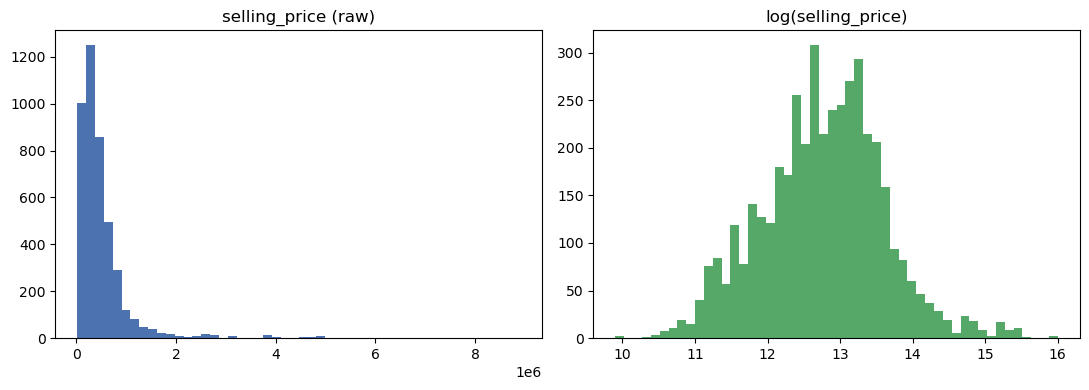

Raw price is heavily right-skewed -> log-transform is justified.


In [29]:
# Quick EDA (Exploratory Data Analysis): compare the raw price
# distribution against the log-transformed price distribution
# Create a figure with 1 row and 2 columns of subplots, placed side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Plot a histogram of the raw selling_price values in the first subplot
axes[0].hist(df["selling_price"], bins=50, color="#4C72B0")
# Set a title for the raw price histogram
axes[0].set_title("selling_price (raw)")
# Plot a histogram of the log-transformed selling_price values in the second subplot
axes[1].hist(np.log(df["selling_price"]), bins=50, color="#55A868")
# Set a title for the log-transformed price histogram
axes[1].set_title("log(selling_price)")
# Automatically adjust subplot spacing so titles/labels don't overlap
plt.tight_layout()
# Render and display the figure
plt.show()
# Print a short, plain-language interpretation of what the histograms show
print("Raw price is heavily right-skewed -> log-transform is justified.")


# Step 7: Train/Test Split

## Objective
Split the data into a training set (used to fit the model) and a held-out test set (used to honestly evaluate it).

## Explanation
80/20 split with a fixed random seed. Row counts should land close to the paper's 3,457 train / 865 test.

## Expected Outcome
Four objects -- `X_train`, `X_test`, `y_train`, `y_test` -- ready to be passed into the regression model.


In [30]:
# Define the list of predictor (feature) columns to use in the model
feature_cols = [
    "age", "km_driven_capped", "owner_rank",
    "fuel_Diesel", "fuel_LPG", "fuel_Petrol",
    "seller_Individual", "seller_Trustmark Dealer",
    "transmission_manual",
]

# Select the feature columns as the input matrix X
X = model_df[feature_cols]
# Select the log-transformed selling price as the target vector y
y = model_df["log_price"]

# Randomly split X and y into training (80%) and testing (20%) sets,
# using a fixed random_state so the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print the resulting number of rows in each split to confirm the sizes
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")


Train: 3457 rows, Test: 865 rows


# Step 8: Fit the OLS Multiple Regression Model

## Objective
Train a multiple linear regression model on the training data using Ordinary Least Squares (OLS).

## Explanation
Using `statsmodels` (rather than sklearn) because it directly reports p-values, confidence intervals, and the diagnostics we need (Durbin-Watson, condition number) alongside the coefficients.

## Expected Outcome
A fitted OLS model (`ols_model`) together with a full statistical summary of its coefficients and fit quality.


In [31]:
# Add a constant (intercept) column of 1s to the training features,
# which statsmodels requires in order to fit an intercept term
X_train_sm = sm.add_constant(X_train)
# Fit an Ordinary Least Squares regression of y_train on X_train_sm
ols_model = sm.OLS(y_train, X_train_sm).fit()
# Print the full statistical summary: coefficients, p-values, R-squared, etc.
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     814.9
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:58:58   Log-Likelihood:                -2328.0
No. Observations:                3457   AIC:                             4676.
Df Residuals:                    3447   BIC:                             4738.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

# Step 9: Evaluate on the Held-Out Test Set

## Objective
Measure how well the trained model generalises to data it has never seen before.

## Explanation
Reported on **both** scales, since they tell different stories:
- **Log scale** -- what the model was actually optimized on.
- **Real price scale** (₹) -- what actually matters to a buyer/seller, after
  converting predictions back with `exp()`. R² is noticeably lower here,
  because errors on expensive cars get magnified once back-transformed.

## Expected Outcome
A summary table of R², Adjusted R², RMSE, MAE, and MAPE on both the log and real-price scales.


In [32]:
# Add a constant column to the test features to match the training design matrix
X_test_sm = sm.add_constant(X_test, has_constant="add")
# Generate predictions (on the log scale) for the test set
y_pred_log = ols_model.predict(X_test_sm)

# n = number of test observations, p = number of predictor features
n, p = X_test.shape

# Compute R-squared on the log scale
r2_log = r2_score(y_test, y_pred_log)
# Compute Adjusted R-squared (penalises R2 for the number of predictors used)
adj_r2_log = 1 - (1 - r2_log) * (n - 1) / (n - p - 1)
# Compute Root Mean Squared Error on the log scale
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
# Compute Mean Absolute Error on the log scale
mae_log = mean_absolute_error(y_test, y_pred_log)

# Convert the actual log-price test values back to real rupee prices
y_test_real = np.exp(y_test)
# Convert the predicted log-price values back to real rupee prices
y_pred_real = np.exp(y_pred_log)

# Compute R-squared on the real (rupee) price scale
r2_real = r2_score(y_test_real, y_pred_real)
# Compute Adjusted R-squared on the real price scale
adj_r2_real = 1 - (1 - r2_real) * (n - 1) / (n - p - 1)
# Compute Root Mean Squared Error on the real price scale
rmse_real = mean_squared_error(y_test_real, y_pred_real) ** 0.5
# Compute Mean Absolute Error on the real price scale
mae_real = mean_absolute_error(y_test_real, y_pred_real)
# Compute Mean Absolute Percentage Error on the real price scale
mape_real = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

# Assemble all metrics into a single summary DataFrame for easy comparison
metrics = pd.DataFrame({
    "Scale": ["Log", "Real price (₹)"],
    "R2": [round(r2_log, 3), round(r2_real, 3)],
    "Adj R2": [round(adj_r2_log, 3), round(adj_r2_real, 3)],
    "RMSE": [round(rmse_log, 3), round(rmse_real)],
    "MAE": [round(mae_log, 3), round(mae_real)],
    "MAPE": ["-", f"{mape_real:.1f}%"],
})
# Display the metrics table
metrics


,Scale,R2,Adj R2,RMSE,MAE,MAPE
0,Log,0.703,0.700,0.456,0.357,-
1,Real price (₹),0.595,0.591,329453.000,170909.000,38.2%


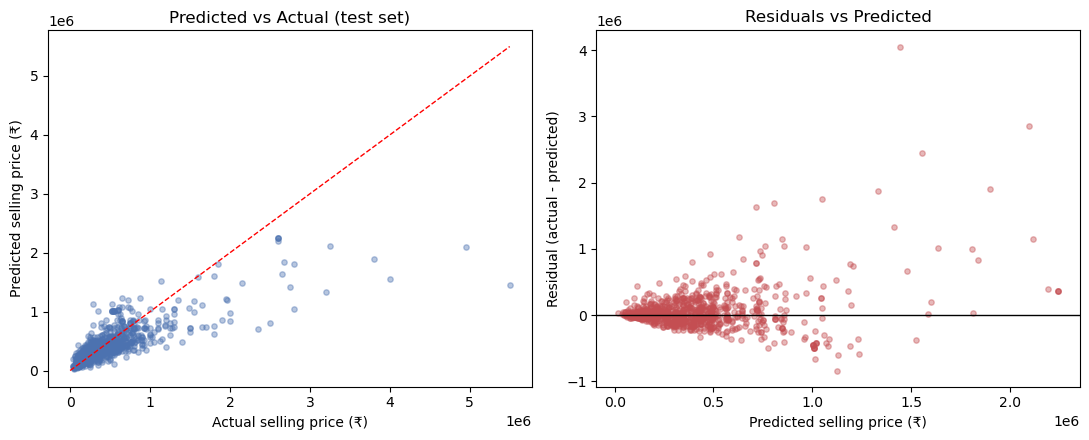

In [33]:
# Create a figure with 1 row and 2 columns of subplots, placed side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Scatter plot of actual vs predicted prices (left subplot)
axes[0].scatter(y_test_real, y_pred_real, alpha=0.4, s=15, color="#4C72B0")
# Define the axis limits so the diagonal reference line spans the full range
lims = [0, max(y_test_real.max(), y_pred_real.max())]
# Draw a red dashed diagonal line representing "perfect prediction"
axes[0].plot(lims, lims, "r--", linewidth=1)
# Label the x-axis of the left subplot
axes[0].set_xlabel("Actual selling price (₹)")
# Label the y-axis of the left subplot
axes[0].set_ylabel("Predicted selling price (₹)")
# Set the title of the left subplot
axes[0].set_title("Predicted vs Actual (test set)")

# Calculate residuals: the difference between actual and predicted prices
residuals = y_test_real - y_pred_real
# Scatter plot of residuals against predicted prices (right subplot)
axes[1].scatter(y_pred_real, residuals, alpha=0.4, s=15, color="#C44E52")
# Draw a horizontal black line at residual = 0 for reference
axes[1].axhline(0, color="black", linewidth=1)
# Label the x-axis of the right subplot
axes[1].set_xlabel("Predicted selling price (₹)")
# Label the y-axis of the right subplot
axes[1].set_ylabel("Residual (actual - predicted)")
# Set the title of the right subplot
axes[1].set_title("Residuals vs Predicted")

# Automatically adjust subplot spacing so titles/labels don't overlap
plt.tight_layout()
# Render and display the figure
plt.show()


# Step 10: Regression Diagnostics

## Objective
Check whether the fitted OLS model satisfies the key assumptions of linear regression.

## Explanation
- **Durbin-Watson**: tests for autocorrelation in residuals. Values near 2.0
  indicate no significant autocorrelation (rows are independent listings, so
  this is expected and desired).
- **VIF (Variance Inflation Factor)**: flags multicollinearity between
  predictors. VIF > 5–10 signals a feature is highly correlated with other
  features. **Note:** VIF must be computed on the design matrix *without* the
  intercept column -- including the constant artificially inflates VIF for
  dummy-heavy models (a common statsmodels gotcha).

## Expected Outcome
A Durbin-Watson statistic and a VIF table confirming the model's residuals and predictors behave as expected.


In [34]:
# Compute the Durbin-Watson statistic on the model's residuals
# to test for autocorrelation between consecutive residuals
dw = durbin_watson(ols_model.resid)
# Print the statistic, noting that a value near 2.0 means no autocorrelation
print(f"Durbin-Watson statistic: {dw:.2f}  (2.0 = no autocorrelation)")


Durbin-Watson statistic: 1.99  (2.0 = no autocorrelation)


In [35]:
# Create an empty DataFrame to hold the VIF results
vif_data = pd.DataFrame()
# Store the feature (predictor) names in a 'feature' column
vif_data["feature"] = X_train.columns
# Compute the Variance Inflation Factor for each feature (excluding the
# intercept, since X_train here has no constant column)
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
# Sort the features by VIF value, highest (most collinear) first
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
# Display the sorted VIF table
vif_data


,feature,VIF
0,age,18.016992
1,fuel_Petrol,9.874429
2,transmission_manual,9.535020
3,fuel_Diesel,8.756502
4,km_driven_capped,5.348444
5,seller_Individual,4.784573
6,owner_rank,1.885749
7,fuel_LPG,1.111166
8,seller_Trustmark Dealer,1.102355


`transmission_manual` and the fuel dummies show the highest VIF (~6–9,
consistent with the paper) -- manual transmission and fuel type are
correlated with each other and with age in this market (e.g. older, cheaper
cars are overwhelmingly manual + petrol/diesel), but none crosses the
severe-multicollinearity threshold of ~10.

# Step 11: Interpreting Coefficients

## Objective
Translate the raw regression coefficients into an intuitive, real-world "percentage impact on price" for each feature.

## Explanation
Since the target is `log(price)`, each coefficient's real-world meaning is a
**percentage** effect on price, computed as `(exp(coef) - 1) × 100`, holding
all other features constant.

## Expected Outcome
A ranked table showing which features push price up or down, and by roughly how many percentage points.


In [36]:
# Extract the model's fitted coefficients (excluding the intercept/'const')
# into a DataFrame with a single 'coef' column
coef_table = ols_model.params.drop("const").to_frame("coef")
# Convert each log-scale coefficient into a percentage price impact
coef_table["pct_price_impact"] = (np.exp(coef_table["coef"]) - 1) * 100
# Attach the corresponding p-value for each coefficient
coef_table["p_value"] = ols_model.pvalues.drop("const")
# Sort the table by percentage price impact, smallest (most negative) first
coef_table = coef_table.sort_values("pct_price_impact")
# Display the final coefficient interpretation table
coef_table


,coef,pct_price_impact,p_value
transmission_manual,-7.894619e-01,-54.591093,2.762940e-166
seller_Individual,-1.607626e-01,-14.850585,6.174327e-15
age,-1.131693e-01,-10.700049,0.000000e+00
fuel_LPG,-6.295255e-02,-6.101197,6.599593e-01
owner_rank,-4.423398e-02,-4.326993,7.939498e-04
km_driven_capped,-6.806057e-07,-0.000068,4.845532e-03
fuel_Petrol,3.215168e-02,3.267413,6.887777e-01
seller_Trustmark Dealer,3.058435e-01,35.776981,6.917459e-08
fuel_Diesel,5.494048e-01,73.222178,8.631897e-12


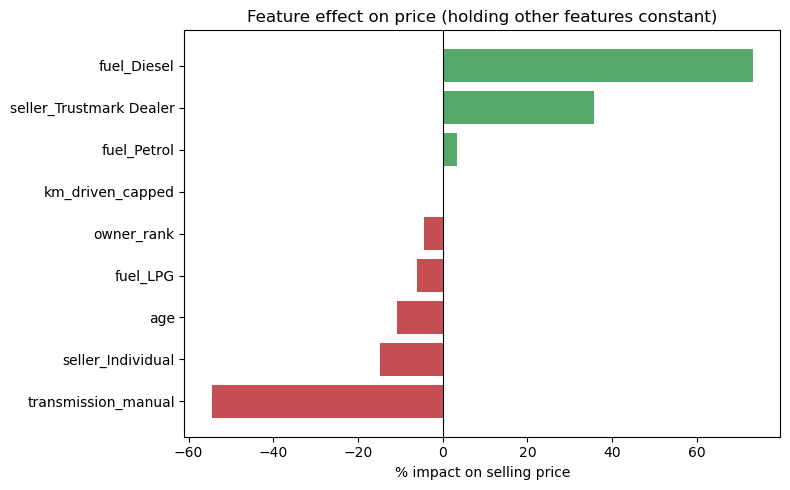

In [37]:
# Create a single figure/axes for the horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 5))
# Choose red for negative price impacts and green for positive ones
colors = ["#C44E52" if v < 0 else "#55A868" for v in coef_table["pct_price_impact"]]
# Plot a horizontal bar for each feature's percentage price impact
ax.barh(coef_table.index, coef_table["pct_price_impact"], color=colors)
# Draw a vertical black reference line at 0% impact
ax.axvline(0, color="black", linewidth=0.8)
# Label the x-axis
ax.set_xlabel("% impact on selling price")
# Set the chart title
ax.set_title("Feature effect on price (holding other features constant)")
# Automatically adjust spacing so labels aren't cut off
plt.tight_layout()
# Render and display the chart
plt.show()


**Reading the chart:**
- Each additional year of `age` and Manual transmission (vs Automatic) are
  the strongest negative drivers of price.
- Diesel and Trustmark Dealer listings carry a meaningful price premium.
- Individual sellers price lower than Dealers, on average, for the same car
  attributes.

# Step 12: Extension -- Good Deal / Fairly Priced / Overpriced Tool

## Objective
Turn the regression model into a practical tool that flags whether a given listing looks like a good deal.

## Explanation
Using the model's predicted price as a fair-market benchmark: if a listing's
actual price is more than 10% below prediction it's flagged a **Good Deal**;
more than 10% above, **Overpriced**; otherwise **Fairly Priced**.

## Expected Outcome
Every test-set listing is labelled Good Deal, Fairly Priced, or Overpriced, and the five biggest "Good Deal" listings are shown.


In [38]:
# Define a function that classifies a listing based on how far its actual
# price sits from the model's predicted (fair-market) price
def price_flag(actual, predicted, band=0.10):
    # Compute the percentage difference between actual and predicted price
    diff_pct = (actual - predicted) / predicted
    # If actual price is more than 'band' (10%) below prediction -> Good Deal
    if diff_pct < -band:
        return "Good Deal"
    # If actual price is more than 'band' (10%) above prediction -> Overpriced
    elif diff_pct > band:
        return "Overpriced"
    # Otherwise the price is close to the model's prediction -> Fairly Priced
    return "Fairly Priced"


# Build a DataFrame combining the actual and predicted real-price values,
# keeping the same index as the test set
test_results = pd.DataFrame({
    "actual_price": y_test_real.values,
    "predicted_price": y_pred_real.values,
}, index=y_test.index)
# Compute the percentage difference between actual and predicted price for each row
test_results["diff_pct"] = (test_results["actual_price"] - test_results["predicted_price"]) / test_results["predicted_price"] * 100
# Apply the price_flag function row-by-row to classify each listing
test_results["flag"] = test_results.apply(lambda r: price_flag(r["actual_price"], r["predicted_price"]), axis=1)

# Print how many listings fall into each classification category
print(test_results["flag"].value_counts())
# Show the 5 listings with the lowest (most negative) price difference,
# i.e. the biggest "Good Deal" candidates
test_results.sort_values("diff_pct").head(5)


flag
Overpriced       371
Good Deal        317
Fairly Priced    177
Name: count, dtype: int64


,actual_price,predicted_price,diff_pct,flag
877,40000.0,196903.532717,-79.685484,Good Deal
889,100000.0,434124.751866,-76.965147,Good Deal
682,58000.0,245413.532756,-76.366421,Good Deal
2065,73000.0,301728.594771,-75.806072,Good Deal
856,60000.0,243413.030013,-75.350539,Good Deal


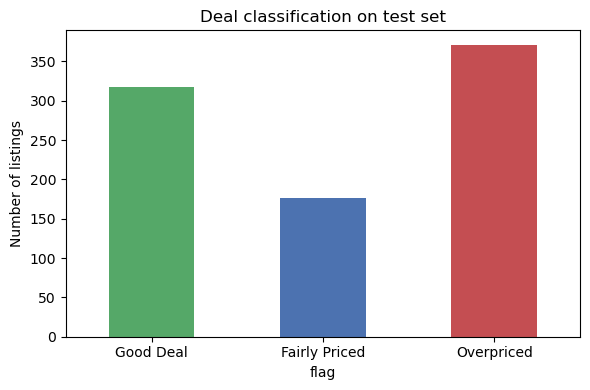

In [39]:
# Create a single figure/axes for the bar chart
fig, ax = plt.subplots(figsize=(6, 4))
# Count how many listings fall into each flag category, in a fixed order,
# and plot the counts as a bar chart
test_results["flag"].value_counts().reindex(["Good Deal", "Fairly Priced", "Overpriced"]).plot(
    kind="bar", color=["#55A868", "#4C72B0", "#C44E52"], ax=ax
)
# Label the y-axis
ax.set_ylabel("Number of listings")
# Set the chart title
ax.set_title("Deal classification on test set")
# Keep the category labels on the x-axis horizontal (not rotated)
plt.xticks(rotation=0)
# Automatically adjust spacing so labels aren't cut off
plt.tight_layout()
# Render and display the chart
plt.show()


# Step 13: Summary & Conclusions

## 10. Summary

| Metric | Log scale | Real price scale |
|---|---|---|
| R² | ~0.70 | ~0.60 |
| Adjusted R² | ~0.70 | ~0.59 |
| RMSE | ~0.46 | ~₹329K |
| MAE | ~0.36 | ~₹171K |
| MAPE | – | ~38% |

- Durbin-Watson ≈ 2.0 → residuals are not autocorrelated, a healthy sign for
  OLS assumptions.
- VIF values (after correcting for the intercept-inflation issue) show
  moderate but non-severe multicollinearity between transmission, fuel type,
  and age.
- `age` and `transmission` are the dominant price drivers; fuel type and
  seller type matter but less so.

**Observations and Recommendations**
- ~38% MAPE means individual price predictions can be off substantially --
  this model explains *average* price patterns well but isn't precise enough
  for pinpointing a single car's exact resale value.
- The dataset lacks engine/mileage/power specs, which likely caps how much variance any linear
  model can explain here.
- Next steps: try a tree-based model (Random Forest/XGBoost) as a benchmark,
  and/or bring in engine/mileage features from a richer dataset if available.